# Support Vector Machines for Spend Category Prediction

This notebook applies SVM models to classify tourist spending category (0/1/2).

We will:
- Load preprocessed datasets
- Train baseline Linear SVM
- Train RBF kernel SVM (non-linear classifier)
- Perform hyperparameter tuning using GridSearchCV
- Export predictions and save trained models

SVMs often outperform logistic regression for non-linear decision boundaries,
especially when categories overlap (e.g., medium vs high spend).

### Import Libraries

In [11]:
import pandas as pd
import numpy as np

from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import joblib
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


### Load Datasets

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_val   = pd.read_csv("../data/processed/X_val.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val   = pd.read_csv("../data/processed/y_val.csv").squeeze()

test = pd.read_csv("../data/processed/test.csv")
test_trip_id = pd.read_csv("../data/processed/test_trip_id.csv").squeeze()

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

Train: (10096, 79)
Val: (2524, 79)
Test: (5852, 79)
y_train: (10096,)
y_val: (2524,)


### BaseLine Linear SVM (LinearSVC)

In [4]:
svm_linear = LinearSVC(
    C=1.0,
    max_iter=10000
)

svm_linear.fit(X_train, y_train)

# Predict
val_preds_linear = svm_linear.predict(X_val)

acc_lin = accuracy_score(y_val, val_preds_linear)
f1_lin  = f1_score(y_val, val_preds_linear, average="macro")

print("Baseline LinearSVC Performance")
print("---------------------------------")
print(f"Accuracy: {acc_lin:.4f}")
print(f"F1 Macro: {f1_lin:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds_linear))

# Convergence check
try:
    if hasattr(svm_linear, 'n_iter_') and any(i >= svm_linear.max_iter for i in svm_linear.n_iter_):
        print("\nNOTE: LinearSVC may NOT have fully converged.\n")
    else:
        print("\nLinearSVC converged successfully.\n")
except:
    print("\nCould not verify convergence.\n")


joblib.dump(svm_linear, "../models/svm_linear.joblib")

test_preds_linear = svm_linear.predict(test)

submission_linear = pd.DataFrame({
    "trip_id": test_trip_id,
    "spend_category": test_preds_linear
})

submission_linear.to_csv("../submissions/svm_linear.csv", index=False)

print("LinearSVC model saved & submission generated.")

Baseline LinearSVC Performance
---------------------------------
Accuracy: 0.7314
F1 Macro: 0.5638

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.86      0.84      1249
         1.0       0.64      0.75      0.69       982
         2.0       0.63      0.09      0.16       293

    accuracy                           0.73      2524
   macro avg       0.69      0.57      0.56      2524
weighted avg       0.72      0.73      0.70      2524


Could not verify convergence.

LinearSVC model saved & submission generated.


### Baseline RBF SVM

In [5]:
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced"  # IMPORTANT for class imbalance!
)

svm_rbf.fit(X_train, y_train)

val_preds_rbf = svm_rbf.predict(X_val)

acc_rbf = accuracy_score(y_val, val_preds_rbf)
f1_rbf  = f1_score(y_val, val_preds_rbf, average="macro")

print("Baseline RBF SVC Performance")
print("------------------------------")
print(f"Accuracy: {acc_rbf:.4f}")
print(f"F1 Macro: {f1_rbf:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds_rbf))

joblib.dump(svm_rbf, "../models/svm_rbf.joblib")

test_preds_rbf = svm_rbf.predict(test)

submission_rbf = pd.DataFrame({
    "trip_id": test_trip_id,
    "spend_category": test_preds_rbf
})

submission_rbf.to_csv("../submissions/svm_rbf.csv", index=False)

print("RBF SVM saved and submission generated.")

Baseline RBF SVC Performance
------------------------------
Accuracy: 0.6410
F1 Macro: 0.5764

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.85      0.84      1249
         1.0       0.64      0.32      0.43       982
         2.0       0.32      0.82      0.46       293

    accuracy                           0.64      2524
   macro avg       0.60      0.66      0.58      2524
weighted avg       0.70      0.64      0.64      2524

RBF SVM saved and submission generated.


### Tuned RBF SVM

In [6]:
param_grid_rbf = {
    "C": [0.5, 1, 2, 5],
    "gamma": ["scale", "auto"],
    "class_weight": ["balanced"],
}

svm_rbf_base = SVC(
    kernel="rbf",
    decision_function_shape="ovr",
)

grid_rbf = GridSearchCV(
    estimator=svm_rbf_base,
    param_grid=param_grid_rbf,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1,
)

grid_rbf.fit(X_train, y_train)

print("\nBest Hyperparameters Found:")
print(grid_rbf.best_params_)
print(f"Best CV F1 Macro: {grid_rbf.best_score_:.4f}")

best_rbf = grid_rbf.best_estimator_
val_preds_rbf_tuned = best_rbf.predict(X_val)

acc_rbf_tuned = accuracy_score(y_val, val_preds_rbf_tuned)
f1_rbf_tuned  = f1_score(y_val, val_preds_rbf_tuned, average="macro")

print("\nTuned RBF SVM Performance")
print("---------------------------")
print(f"Accuracy: {acc_rbf_tuned:.4f}")
print(f"F1 Macro: {f1_rbf_tuned:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds_rbf_tuned))

joblib.dump(best_rbf, "../models/svm_rbf_tuned.joblib")

test_preds_rbf_tuned = best_rbf.predict(test)

submission_rbf_tuned = pd.DataFrame({
    "trip_id": test_trip_id,
    "spend_category": test_preds_rbf_tuned
})

submission_rbf_tuned.to_csv("../submissions/svm_rbf_tuned.csv", index=False)

print("Tuned RBF SVM saved & submission generated.")


Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Hyperparameters Found:
{'C': 5, 'class_weight': 'balanced', 'gamma': 'auto'}
Best CV F1 Macro: 0.6556

Tuned RBF SVM Performance
---------------------------
Accuracy: 0.7139
F1 Macro: 0.6671

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83      1249
         1.0       0.68      0.57      0.62       982
         2.0       0.45      0.71      0.55       293

    accuracy                           0.71      2524
   macro avg       0.65      0.70      0.67      2524
weighted avg       0.73      0.71      0.72      2524

Tuned RBF SVM saved & submission generated.
[CV] END .............C=1, class_weight=balanced, gamma=auto; total time=  18.4s
[CV] END .............C=2, class_weight=balanced, gamma=auto; total time=  17.4s
[CV] END ...........C=0.5, class_weight=balanced, gamma=auto; total time=  18.5s
[CV] END .............C=2, class_weight=balanced, g

### PCA + SVM (RBF Kernel)

In [8]:
PCA_COMPONENTS = 60

pca_svm = Pipeline([
    ("pca", PCA(n_components=PCA_COMPONENTS, random_state=42)),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced"))
])

pca_svm.fit(X_train, y_train)

val_preds_pca = pca_svm.predict(X_val)

print("\nPCA + SVM (Baseline)")
print("-------------------------------")
print(f"Accuracy: {accuracy_score(y_val, val_preds_pca):.4f}")
print(f"F1 Macro: {f1_score(y_val, val_preds_pca, average='macro'):.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds_pca))


# Important: use legal PCA sizes
max_allowed = min(X_train.shape[0], X_train.shape[1]) - 1
print("Max allowed PCA:", max_allowed)

# Only choose values <= limit
pca_range = [min(v, max_allowed) for v in [20, 40, 60]]
print("Using PCA values:", pca_range)

param_grid_pca = {
    "pca__n_components": pca_range,
    "svm__C": [0.5, 1, 2],
    "svm__gamma": ["scale"],
}

pca_svm_base = Pipeline([
    ("pca", PCA(random_state=42)),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

grid_pca = GridSearchCV(
    estimator=pca_svm_base,
    param_grid=param_grid_pca,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_pca.fit(X_train, y_train)

print("\nBest Hyperparameters Found:")
print(grid_pca.best_params_)
print(f"Best CV F1 Macro: {grid_pca.best_score_:.4f}")

best_pca_svm = grid_pca.best_estimator_
val_preds_pca_tuned = best_pca_svm.predict(X_val)



print("\nTuned PCA + RBF SVM Performance")
print("------------------------------------")
print(f"Accuracy: {accuracy_score(y_val, val_preds_pca_tuned):.4f}")
print(f"F1 Macro: {f1_score(y_val, val_preds_pca_tuned, average='macro'):.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds_pca_tuned))



joblib.dump(best_pca_svm, "../models/svm_pca_tuned.joblib")

test_preds_pca = best_pca_svm.predict(test)

submission_pca = pd.DataFrame({
    "trip_id": test_trip_id,
    "spend_category": test_preds_pca
})

submission_pca.to_csv("../submissions/svm_pca_tuned.csv", index=False)

print("\nPCA+SVM model saved & submission generated.")


PCA + SVM (Baseline)
-------------------------------
Accuracy: 0.6577
F1 Macro: 0.5992

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.84      0.84      1249
         1.0       0.66      0.38      0.48       982
         2.0       0.34      0.80      0.48       293

    accuracy                           0.66      2524
   macro avg       0.61      0.67      0.60      2524
weighted avg       0.71      0.66      0.66      2524

Max allowed PCA: 78
Using PCA values: [20, 40, 60]
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best Hyperparameters Found:
{'pca__n_components': 60, 'svm__C': 2, 'svm__gamma': 'scale'}
Best CV F1 Macro: 0.5927

Tuned PCA + RBF SVM Performance
------------------------------------
Accuracy: 0.6616
F1 Macro: 0.6047

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.84      0.83      1249
         1.0       0.66      0.39      0.49

### Model Comparison


SVM Model Comparison
--------------------------------------
                model  accuracy  f1_macro
           Linear SVC  0.731379  0.563831
   RBF SVC (baseline)  0.641046  0.576371
      RBF SVC (tuned)  0.713946  0.667120
        PCA + RBF SVC  0.657686  0.599239
PCA + RBF SVC (tuned)  0.661648  0.604691

Comparison saved → ../models/svm_model_comparison.csv


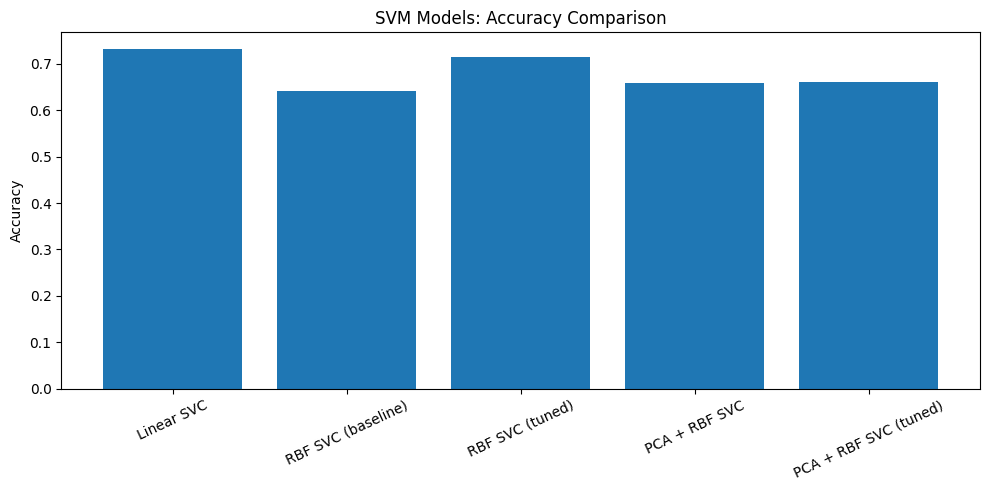

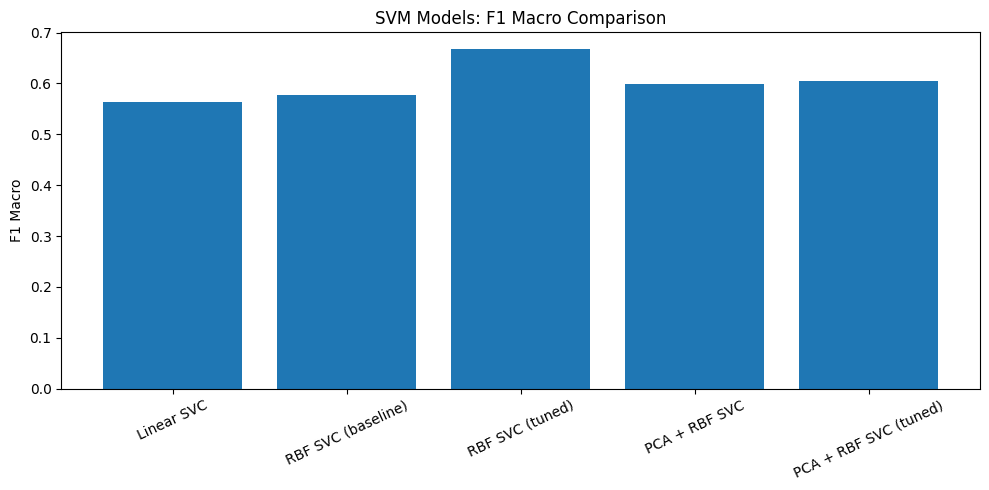

[CV] END ...pca__n_components=20, svm__C=1, svm__gamma=scale; total time=   8.8s
[CV] END ...pca__n_components=40, svm__C=2, svm__gamma=scale; total time=  12.8s
[CV] END ...pca__n_components=20, svm__C=2, svm__gamma=scale; total time=   8.2s
[CV] END ...pca__n_components=40, svm__C=1, svm__gamma=scale; total time=  13.6s
[CV] END ...pca__n_components=20, svm__C=2, svm__gamma=scale; total time=   8.1s
[CV] END ...pca__n_components=40, svm__C=1, svm__gamma=scale; total time=  13.9s
[CV] END .pca__n_components=20, svm__C=0.5, svm__gamma=scale; total time=  10.2s
[CV] END .pca__n_components=60, svm__C=0.5, svm__gamma=scale; total time=  16.8s
[CV] END .pca__n_components=20, svm__C=0.5, svm__gamma=scale; total time=  10.5s
[CV] END .pca__n_components=60, svm__C=0.5, svm__gamma=scale; total time=  16.6s
[CV] END .pca__n_components=20, svm__C=0.5, svm__gamma=scale; total time=  10.1s
[CV] END .pca__n_components=60, svm__C=0.5, svm__gamma=scale; total time=  17.5s
[CV] END .pca__n_components=

In [12]:
svm_comparison = pd.DataFrame({
    "model": [
        "Linear SVC",
        "RBF SVC (baseline)",
        "RBF SVC (tuned)",
        "PCA + RBF SVC",
        "PCA + RBF SVC (tuned)"
    ],
    "accuracy": [
        accuracy_score(y_val, val_preds_linear),
        accuracy_score(y_val, val_preds_rbf),
        accuracy_score(y_val, val_preds_rbf_tuned),
        accuracy_score(y_val, val_preds_pca),
        accuracy_score(y_val, val_preds_pca_tuned),
    ],
    "f1_macro": [
        f1_score(y_val, val_preds_linear, average="macro"),
        f1_score(y_val, val_preds_rbf, average="macro"),
        f1_score(y_val, val_preds_rbf_tuned, average="macro"),
        f1_score(y_val, val_preds_pca, average="macro"),
        f1_score(y_val, val_preds_pca_tuned, average="macro"),
    ]
})

print("\nSVM Model Comparison")
print("--------------------------------------")
print(svm_comparison.to_string(index=False))

# Save summary
svm_comparison.to_csv("../models/svm_model_comparison.csv", index=False)
print("\nComparison saved → ../models/svm_model_comparison.csv")

plt.figure(figsize=(10,5))
plt.bar(svm_comparison["model"], svm_comparison["accuracy"])
plt.title("SVM Models: Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.bar(svm_comparison["model"], svm_comparison["f1_macro"])
plt.title("SVM Models: F1 Macro Comparison")
plt.ylabel("F1 Macro")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()